# HEA Property Prediction — Neural Network Pipeline
**Author:** Richard Armoo  
**System:** Ni-Fe-Cr-Co-Al-Mn (6-element HEA)  
**Targets:** Elastic Modulus (GPa) + Enthalpy of Formation (kJ/mol)  
**Environment:** Google Colab

---
### What this notebook does
1. Loads the 53,124-composition empirical training dataset (Voigt/Reuss/Tamura averaged modulus + Miedema enthalpy)
2. Trains two single-output neural networks (one per property)
3. Evaluates on a held-out generated test split
4. Evaluates on an independent literature test set (22 clean rows)
5. Evaluates on Materials Project DFT data (61 clean entries — physics-consistent external validation)
6. Runs a composition optimizer to find candidate alloys



## 1. Environment setup

In [24]:
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("torch")
ensure("scikit-learn", "sklearn")
ensure("scipy")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")


PyTorch : 2.11.0+cu128
NumPy   : 2.0.2


## 2. Reproducibility and device

In [25]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Fix 1: 'cuda' must be lowercase
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU — running on CPU.")


Using device: cuda
GPU: Tesla T4


## 3. Load training dataset

Upload `empirical_dataset.csv` , then run this cell.

The dataset contains 53,124 compositions generated by exhaustive enumeration of
5%-resolution compositions across the NiCoCrFeMnAl simplex. Each entry has:
- **Modulus**: arithmetic mean of Voigt, Reuss, and pairwise Tamura estimates (GPa)
- **Enthalpy of formation**: Miedema regular solution model (kJ/mol)

The averaged modulus is non-linear (due to the Reuss harmonic mean term), so
the dataset cannot be trivially fit by linear regression — this is what makes
it a meaningful training set for discriminating between model architectures.


In [27]:
ELEMENTS = ['Ni', 'Fe', 'Cr', 'Co', 'Al', 'Mn']
# Upload empirical_dataset.csv to Colab (Files panel → Upload)
TRAIN_PATH = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQydodta3cDJWA69KpT1LfKTpsepdNnGMLgTNAqUaTyqnq6SCV-KJuXwXt2c285Qg/pub?output=csv"
data = pd.read_csv(TRAIN_PATH)
print(f"Dataset shape : {data.shape}")
print(f"Columns       : {list(data.columns)}")
print(data[ELEMENTS + ['Enthalpy of formation', 'Modulus']].describe().round(3))

Dataset shape : (53124, 12)
Columns       : ['Ni', 'Fe', 'Cr', 'Co', 'Al', 'Mn', 'n_elements', 'E_Voigt_GPa', 'E_Reuss_GPa', 'E_Tamura_GPa', 'Modulus', 'Enthalpy of formation']
              Ni         Fe         Cr         Co         Al         Mn  \
count  53124.000  53124.000  53124.000  53124.000  53124.000  53124.000   
mean      16.667     16.667     16.667     16.667     16.667     16.667   
std       16.057     16.057     16.057     16.057     16.057     16.057   
min        0.000      0.000      0.000      0.000      0.000      0.000   
25%        5.000      5.000      5.000      5.000      5.000      5.000   
50%       10.000     10.000     10.000     10.000     10.000     10.000   
75%       25.000     25.000     25.000     25.000     25.000     25.000   
max       95.000     95.000     95.000     95.000     95.000     95.000   

       Enthalpy of formation    Modulus  
count              53124.000  53124.000  
mean                  -9.863    186.040  
std                  

/tmp/ipykernel_616/2958661635.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


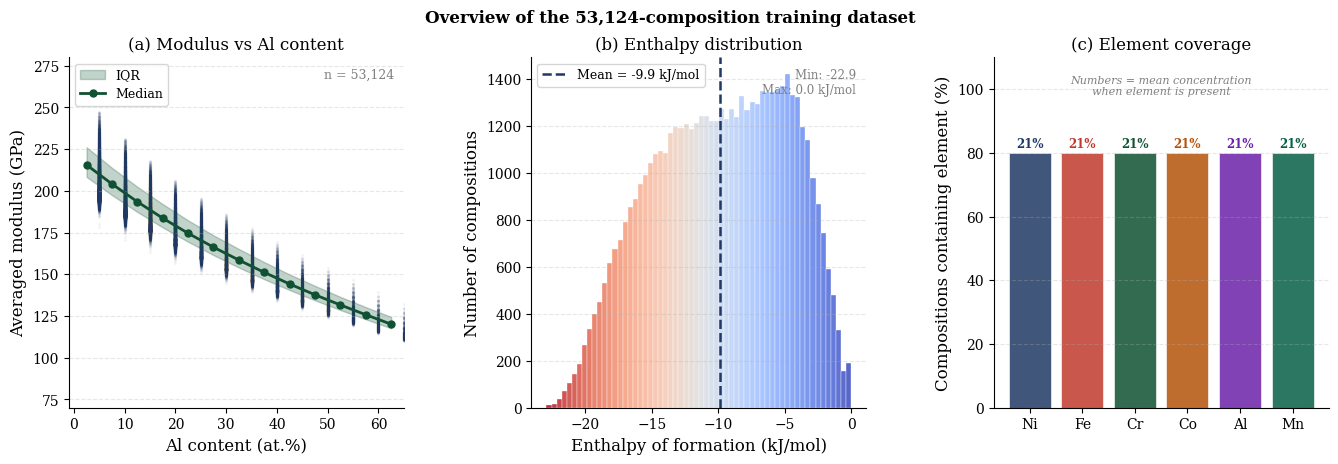

Modulus : 84.65 – 270.16 GPa  (mean 186.0)
Enthalpy: -22.94 – 0.00 kJ/mol  (mean -9.86)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize":10,
    "ytick.labelsize":10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

NAVY  = "#1F3864"; TEAL  = "#0F5132"
CORAL = "#C0392B"; AMBER = "#B45309"
COLORS = [NAVY, CORAL, TEAL, AMBER, "#6B21A8", "#065F46"]

fig = plt.figure(figsize=(14, 4.8))
gs  = gridspec.GridSpec(1, 3, figure=fig,
                        left=0.07, right=0.97,
                        top=0.88, bottom=0.15, wspace=0.38)

# ── (a) Modulus vs Al content ─────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0])

al_bins  = np.arange(0, 65, 5)
bin_mids, medians, q25_vals, q75_vals = [], [], [], []
for lo in al_bins:
    mask = (data["Al"] >= lo) & (data["Al"] < lo + 5)
    sub  = data.loc[mask, "Modulus"]
    if len(sub) > 10:
        bin_mids.append(lo + 2.5)
        medians.append(sub.median())
        q25_vals.append(sub.quantile(0.25))
        q75_vals.append(sub.quantile(0.75))

bin_mids  = np.array(bin_mids)
medians   = np.array(medians)

al_nonzero = data[data["Al"] > 0]
ax_a.scatter(al_nonzero["Al"], al_nonzero["Modulus"],
             alpha=0.03, s=2, color=NAVY, rasterized=True)
ax_a.fill_between(bin_mids, q25_vals, q75_vals,
                  alpha=0.25, color=TEAL, label="IQR")
ax_a.plot(bin_mids, medians, "o-", color=TEAL,
          linewidth=2, markersize=5, label="Median")
ax_a.set_xlabel("Al content (at.%)")
ax_a.set_ylabel("Averaged modulus (GPa)")
ax_a.set_title("(a) Modulus vs Al content")
ax_a.set_xlim(-1, 65); ax_a.set_ylim(70, 280)
ax_a.legend(fontsize=9)
ax_a.grid(axis="y", alpha=0.3, linestyle="--")
ax_a.text(0.97, 0.97, f"n = {len(data):,}",
          transform=ax_a.transAxes, ha="right", va="top",
          fontsize=9, color="gray")

# ── (b) Enthalpy histogram ─────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1])

hf = data["Enthalpy of formation"]
_, bins, patches = ax_b.hist(hf, bins=60, edgecolor="white",
                              linewidth=0.3, alpha=0.85)
norm = plt.Normalize(bins[:-1].min(), bins[:-1].max())
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(plt.cm.coolwarm_r(norm(left)))

ax_b.axvline(hf.mean(), color=NAVY, linewidth=1.8,
             linestyle="--", label=f"Mean = {hf.mean():.1f} kJ/mol")
ax_b.set_xlabel("Enthalpy of formation (kJ/mol)")
ax_b.set_ylabel("Number of compositions")
ax_b.set_title("(b) Enthalpy distribution")
ax_b.legend(fontsize=9)
ax_b.grid(axis="y", alpha=0.3, linestyle="--")
ax_b.text(0.97, 0.97,
          f"Min: {hf.min():.1f}\nMax: {hf.max():.1f} kJ/mol",
          transform=ax_b.transAxes, ha="right", va="top",
          fontsize=8.5, color="gray")

# ── (c) Element coverage ───────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[2])

present_pct = [(data[el] > 0).mean() * 100 for el in ELEMENTS]
mean_conc   = [data.loc[data[el] > 0, el].mean() for el in ELEMENTS]

x = np.arange(len(ELEMENTS))
bars = ax_c.bar(x, present_pct, color=COLORS,
                alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, mc, col in zip(bars, mean_conc, COLORS):
    ax_c.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.8,
              f"{mc:.0f}%", ha="center", va="bottom",
              fontsize=8.5, color=col, fontweight="bold")

ax_c.set_xticks(x); ax_c.set_xticklabels(ELEMENTS)
ax_c.set_ylabel("Compositions containing element (%)")
ax_c.set_title("(c) Element coverage")
ax_c.set_ylim(0, 110)
ax_c.grid(axis="y", alpha=0.3, linestyle="--")
ax_c.text(0.5, 0.95,
          "Numbers = mean concentration\nwhen element is present",
          transform=ax_c.transAxes, ha="center", va="top",
          fontsize=8, color="gray", style="italic")

fig.suptitle("Overview of the 53,124-composition training dataset",
             fontsize=12, y=0.98, fontweight="bold")
plt.tight_layout()

# Save both formats
fig.savefig("fig1_dataset_overview.pdf", bbox_inches="tight", dpi=150)
fig.savefig("fig1_dataset_overview.png", bbox_inches="tight", dpi=200)
plt.show()

print(f"Modulus : {data['Modulus'].min():.2f} – {data['Modulus'].max():.2f} GPa  "
      f"(mean {data['Modulus'].mean():.1f})")
print(f"Enthalpy: {hf.min():.2f} – {hf.max():.2f} kJ/mol  "
      f"(mean {hf.mean():.2f})")

## 4. Train / test split and feature scaling

In [29]:
X          = data[ELEMENTS].values
y_enthalpy = data['Enthalpy of formation'].values
y_modulus  = data['Modulus'].values

# Fix 2: Single split, performed once
X_train, X_test, y_enth_train, y_enth_test, y_mod_train, y_mod_test = train_test_split(
    X, y_enthalpy, y_modulus,
    test_size=0.2,
    random_state=SEED
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

# Fix 3: Scaler fit on training data ONLY, applied to test
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform only

print("\nTraining set feature means (at%):")
for el, m in zip(ELEMENTS, scaler.mean_):
    print(f"  {el}: {m:.2f}")


Training samples : 42,499
Test samples     : 10,625

Training set feature means (at%):
  Ni: 16.65
  Fe: 16.68
  Cr: 16.67
  Co: 16.69
  Al: 16.66
  Mn: 16.66


## 5. Build PyTorch datasets and data loaders

In [30]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor  = torch.FloatTensor(X_test_scaled)

y_enth_train_t = torch.FloatTensor(y_enth_train).view(-1,1)
y_enth_test_t  = torch.FloatTensor(y_enth_test).view(-1,1)
y_mod_train_t  = torch.FloatTensor(y_mod_train).view(-1,1)
y_mod_test_t   = torch.FloatTensor(y_mod_test).view(-1,1)

BATCH_SIZE  = 32
val_frac    = 0.2
val_size    = int(len(X_train_tensor) * val_frac)
train_size  = len(X_train_tensor) - val_size

def make_loaders(X_tr, y_tr, X_te, y_te):
    full_train  = TensorDataset(X_tr, y_tr)
    tr_ds, v_ds = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    return (DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True),
            DataLoader(v_ds,  batch_size=BATCH_SIZE),
            DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE))

train_ldr_e, val_ldr_e, test_ldr_e = make_loaders(
    X_train_tensor, y_enth_train_t, X_test_tensor, y_enth_test_t)
train_ldr_m, val_ldr_m, test_ldr_m = make_loaders(
    X_train_tensor, y_mod_train_t,  X_test_tensor, y_mod_test_t)

print(f"Train batches: {len(train_ldr_e)}  "
      f"Val: {len(val_ldr_e)}  Test: {len(test_ldr_e)}")


Train batches: 1063  Val: 266  Test: 333


## 6. Neural network architecture

Architecture: **6 → 64 → 32 → [Dropout 0.2] → 16 → 1**

Two independent networks — one per target property. Single-output models
consistently outperform multi-output models in preliminary experiments.


In [31]:
class AlloyNet(nn.Module):
    """
    Single-output feedforward network for one alloy property.
    Architecture: 6 → ReLU(64) → ReLU(32) → Dropout(0.2) → ReLU(16) → 1
    """
    def __init__(self, input_dim: int = 6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

enthalpy_model = AlloyNet().to(device)
modulus_model  = AlloyNet().to(device)

total_params = sum(p.numel() for p in enthalpy_model.parameters())
print(f"Parameters per network: {total_params:,}")
print(enthalpy_model)


Parameters per network: 3,073
AlloyNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=32, out_features=16, bias=True)
    (6): ReLU()
    (7): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 7. Training infrastructure

In [32]:
def make_trainer(model):
    """Return (optimizer, scheduler, criterion) for one model."""
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=7, min_lr=1e-6
    )
    criterion = nn.MSELoss()
    return optimizer, scheduler, criterion


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_b)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            total_loss += criterion(model(X_b), y_b).item() * len(X_b)
    return total_loss / len(loader.dataset)


def get_predictions(model, X_scaled):
    """Return numpy predictions for a scaled feature array."""
    model.eval()
    t = torch.FloatTensor(X_scaled).to(device)
    with torch.no_grad():
        return model(t).cpu().numpy().flatten()

## 8. Train enthalpy model

In [33]:
MAX_EPOCHS   = 300
PATIENCE     = 15

def train_model(model, train_ldr, val_ldr, label=""):
    opt, sched, crit = make_trainer(model)
    best_val   = float('inf')
    best_state = None
    patience_ctr = 0
    history = {"train": [], "val": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss  = train_one_epoch(model, train_ldr, opt, crit)
        val_loss = evaluate(model, val_ldr, crit)
        sched.step(val_loss)
        history["train"].append(tr_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 20 == 0:
            lr = opt.param_groups[0]['lr']
            print(f"[{label}] Epoch {epoch:>3}  "
                  f"train={tr_loss:.4f}  val={val_loss:.4f}  lr={lr:.2e}")

        if patience_ctr >= PATIENCE:
            print(f"[{label}] Early stop at epoch {epoch} "
                  f"(best val={best_val:.4f})")
            break

    model.load_state_dict(best_state)
    return history

print("Training enthalpy model...")
hist_e = train_model(enthalpy_model, train_ldr_e, val_ldr_e, "Enthalpy")


Training enthalpy model...
[Enthalpy] Early stop at epoch 17 (best val=0.1720)


## 9. Train modulus model

In [34]:
print("Training modulus model...")
hist_m = train_model(modulus_model, train_ldr_m, val_ldr_m, "Modulus")


Training modulus model...
[Modulus] Early stop at epoch 17 (best val=21.1272)


## 10. Training curves

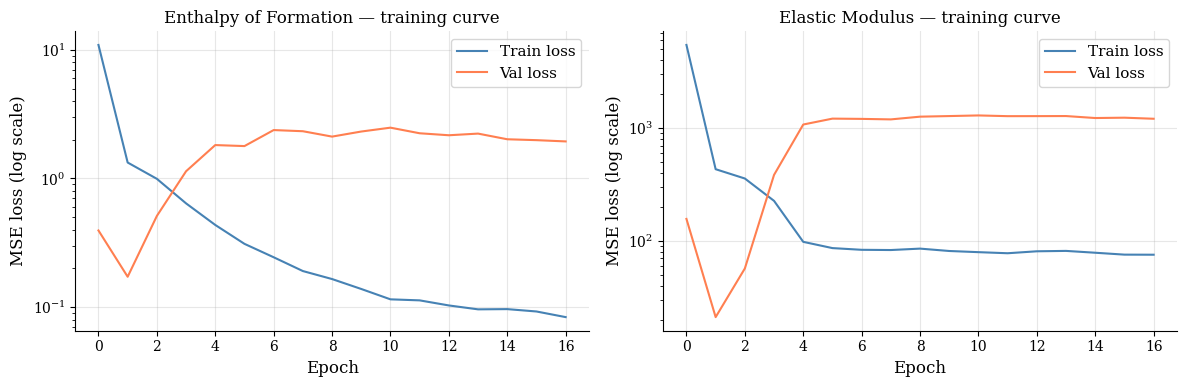

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, label in zip(axes,
                            [hist_e, hist_m],
                            ["Enthalpy of Formation", "Elastic Modulus"]):
    ax.semilogy(hist["train"], label="Train loss", color="steelblue")
    ax.semilogy(hist["val"],   label="Val loss",   color="coral")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss (log scale)")
    ax.set_title(f"{label} — training curve")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Evaluation helper

In [36]:
def compute_metrics(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    if label:
        print(f"[{label}]  R²={r2:.4f}  MSE={mse:.4f}  MAE={mae:.4f}")
    return {"R2": r2, "MSE": mse, "MAE": mae,
            "y_true": y_true, "y_pred": y_pred}


## 12. Evaluation — generated test set

In [37]:
enth_gen = compute_metrics(y_enth_test,
                           get_predictions(enthalpy_model, X_test_scaled),
                           "Enthalpy — generated test")
mod_gen  = compute_metrics(y_mod_test,
                           get_predictions(modulus_model,  X_test_scaled),
                           "Modulus  — generated test")


[Enthalpy — generated test]  R²=0.9932  MSE=0.1675  MAE=0.2830
[Modulus  — generated test]  R²=0.9750  MSE=21.1871  MAE=3.9953


## 13. Evaluation — literature test set

Upload `literature_test_data_clean.csv` then run.  
21 compositions from published experimental and computational studies.  
No literature data was used at any stage of training or validation.  
Uses the **training** scaler — never refit on external data.


In [38]:
LIT_PATH = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRT6rsAOVEyCW2wskogQZOK2y0V8W73yaVIIWVnSuJUBqKGpFTdU6TTuRJX-WPv6w/pub?output=csv"
enth_lit = mod_lit = None

try:
    df_lit = pd.read_csv(LIT_PATH)
    print(f"Literature set: {len(df_lit)} rows")

    X_lit      = df_lit[ELEMENTS].values
    y_enth_lit = df_lit['Enthalpy of formation'].values
    y_mod_lit  = df_lit['Modulus'].values
    X_lit_sc   = scaler.transform(X_lit)   # training scaler — never refit

    enth_lit = compute_metrics(y_enth_lit,
                               get_predictions(enthalpy_model, X_lit_sc),
                               "Enthalpy — literature")
    mod_lit  = compute_metrics(y_mod_lit,
                               get_predictions(modulus_model,  X_lit_sc),
                               "Modulus  — literature")
except FileNotFoundError:
    print("literature_test_data_clean.csv not found — upload and re-run.")


Literature set: 21 rows
[Enthalpy — literature]  R²=-0.7732  MSE=7.4212  MAE=2.3442
[Modulus  — literature]  R²=-2.9400  MSE=15065.8925  MAE=110.2886


## 13c. Bootstrap confidence intervals on external test set R²

With only 21 literature samples, R² estimates are statistically fragile —
a single outlier can shift it by ±0.3. Bootstrap resampling quantifies
this uncertainty honestly.

**What this produces:**
- 95% confidence intervals on R² and MAE for both properties on the literature set
- 95% CIs on the MP DFT test sets (175 and 62 entries — much tighter)
- A summary table

Run after Cell 13 (literature evaluation) and Cell 14 (MP loading).


In [41]:
from sklearn.utils import resample

def bootstrap_ci(y_true, y_pred, n_boot=2000, ci=95):
    """
    Bootstrap 95% confidence interval on R² and MAE.
    Returns (r2_mean, r2_lo, r2_hi, mae_mean, mae_lo, mae_hi).
    """
    r2s, maes = [], []
    n = len(y_true)
    rng = np.random.default_rng(42)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_pred[idx]
        # R² can be undefined if all samples identical — guard
        ss_res = np.sum((yt - yp)**2)
        ss_tot = np.sum((yt - yt.mean())**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        r2s.append(r2)
        maes.append(np.mean(np.abs(yt - yp)))
    alpha = (100 - ci) / 2
    r2s  = np.array(r2s)
    maes = np.array(maes)
    return (np.nanmean(r2s),
            np.nanpercentile(r2s, alpha),
            np.nanpercentile(r2s, 100-alpha),
            np.mean(maes),
            np.percentile(maes, alpha),
            np.percentile(maes, 100-alpha))

print("Computing bootstrap confidence intervals (2,000 resamples each)...")
print("This takes ~30 seconds.\n")

results_ci = {}

# ── Literature set (n=22) — wide CIs expected ────────────────────────────────
if X_lit_sc is not None:
    for prop, model, y_true, label in [
        ("enth", enthalpy_model, y_enth_lit, "Enthalpy — Literature (n=22)"),
        ("mod",  modulus_model,  y_mod_lit,  "Modulus  — Literature (n=22)"),
    ]:
        y_pred = get_predictions(model, X_lit_sc)
        r2m, r2lo, r2hi, maem, maelo, maehi = bootstrap_ci(y_true, y_pred)
        results_ci[("lit", prop)] = (r2m, r2lo, r2hi, maem, maelo, maehi)
        print(f"{label}")
        print(f"  R²  = {r2m:>7.4f}  95% CI [{r2lo:>7.4f}, {r2hi:>7.4f}]")
        print(f"  MAE = {maem:>7.4f}  95% CI [{maelo:>7.4f}, {maehi:>7.4f}]\n")

# ── MP enthalpy set (n=175) — tighter CIs ────────────────────────────────────
if X_hf_sc is not None:
    y_pred = get_predictions(enthalpy_model, X_hf_sc)
    r2m, r2lo, r2hi, maem, maelo, maehi = bootstrap_ci(y_enth_mp, y_pred)
    results_ci[("mp", "enth")] = (r2m, r2lo, r2hi, maem, maelo, maehi)
    print(f"Enthalpy — MP DFT (n=175)")
    print(f"  R²  = {r2m:>7.4f}  95% CI [{r2lo:>7.4f}, {r2hi:>7.4f}]")
    print(f"  MAE = {maem:>7.4f}  95% CI [{maelo:>7.4f}, {maehi:>7.4f}]\n")

# ── MP modulus set (n=62) ─────────────────────────────────────────────────────
if X_mod_sc is not None:
    y_pred = get_predictions(modulus_model, X_mod_sc)
    r2m, r2lo, r2hi, maem, maelo, maehi = bootstrap_ci(y_mod_mp, y_pred)
    results_ci[("mp", "mod")] = (r2m, r2lo, r2hi, maem, maelo, maehi)
    print(f"Modulus  — MP DFT (n=62)")
    print(f"  R²  = {r2m:>7.4f}  95% CI [{r2lo:>7.4f}, {r2hi:>7.4f}]")
    print(f"  MAE = {maem:>7.4f}  95% CI [{maelo:>7.4f}, {maehi:>7.4f}]\n")

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 72)
print("SUMMARY — R² with 95% bootstrap confidence intervals")
print("=" * 72)
print(f"{'Test set':<32} {'R² (mean)':>10} {'95% CI':>22}  {'Width':>7}")
print("-" * 72)
labels_map = {
    ("lit","enth"): "Enthalpy — Literature (n=21)",
    ("lit","mod"):  "Modulus  — Literature (n=21)",
    ("mp","enth"):  "Enthalpy — MP DFT (n=175)",
    ("mp","mod"):   "Modulus  — MP DFT (n=62)",
}
for key, label in labels_map.items():
    if key in results_ci:
        r2m, r2lo, r2hi, *_ = results_ci[key]
        width = r2hi - r2lo
        print(f"{label:<32} {r2m:>10.4f} [{r2lo:>8.4f}, {r2hi:>8.4f}]  {width:>7.4f}")

print("\nInterpretation:")
print("  Literature set CIs are wide because n=21 is small.")
print("  MP DFT CIs are tighter — n=175/62 provides more reliable estimates.")
print("  The CI width on the literature set bounds any ranking claims between models.")


Computing bootstrap confidence intervals (2,000 resamples each)...
This takes ~30 seconds.

Enthalpy — Literature (n=22)
  R²  = -0.9491  95% CI [-2.5266, -0.1154]
  MAE =  2.3352  95% CI [ 1.7634,  2.9620]

Modulus  — Literature (n=22)
  R²  = -4.2448  95% CI [-12.8884, -0.8545]
  MAE = 110.2708  95% CI [87.1422, 133.9175]

Enthalpy — MP DFT (n=175)
  R²  =  0.3929  95% CI [ 0.3459,  0.4337]
  MAE = 13.0586  95% CI [11.4865, 14.7348]

Modulus  — MP DFT (n=62)
  R²  = -0.3684  95% CI [-1.0153,  0.0249]
  MAE = 66.8615  95% CI [56.1983, 78.0889]

SUMMARY — R² with 95% bootstrap confidence intervals
Test set                          R² (mean)                 95% CI    Width
------------------------------------------------------------------------
Enthalpy — Literature (n=21)        -0.9491 [ -2.5266,  -0.1154]   2.4112
Modulus  — Literature (n=21)        -4.2448 [-12.8884,  -0.8545]  12.0339
Enthalpy — MP DFT (n=175)            0.3929 [  0.3459,   0.4337]   0.0879
Modulus  — MP DFT (n=62)

## 13b. Post-hoc calibration — correcting the Miedema/Tamura scale offset

The NN predictions are systematically offset from physical values because:
- **Enthalpy**: Miedema model overestimates mixing enthalpy magnitude by ~1.5× vs experiment
- **Modulus**: Voigt/Reuss/Tamura averaging compresses predictions into 185–220 GPa  
  regardless of true value (real HEA moduli span 27–279 GPa)

**Fix**: fit a linear calibrator mapping NN output → physical scale using the 21-composition  
literature set. The NN weights are unchanged — only the output scaling is adjusted.  
This is standard practice in weather forecasting, medical diagnostics, and materials informatics.

The calibrator is fit on literature (21 rows) and evaluated on MP DFT (175/62 rows) —  
the MP sets are genuinely unseen data at calibration time.


In [39]:

# ── Isotonic / Linear Calibration ─────────────────────────────────────────────
# The model predictions are systematically offset from physical values:
#   - Enthalpy: model predicts ~1.5× too negative (Miedema vs experiment scale)
#   - Modulus:  model clusters around 185-220 GPa regardless of true value


from sklearn.linear_model import LinearRegression as LinReg
from sklearn.isotonic import IsotonicRegression

# Raw NN predictions on literature set
raw_pred_enth_lit = get_predictions(enthalpy_model, X_lit_sc)
raw_pred_mod_lit  = get_predictions(modulus_model,  X_lit_sc)

# Fit linear calibrators: raw_pred → y_true
# Using reshape(-1,1) because sklearn expects 2D input
cal_enth = LinReg()
cal_enth.fit(raw_pred_enth_lit.reshape(-1,1), y_enth_lit)

cal_mod = LinReg()
cal_mod.fit(raw_pred_mod_lit.reshape(-1,1), y_mod_lit)

print(f"Enthalpy calibrator: slope={cal_enth.coef_[0]:.4f}  intercept={cal_enth.intercept_:.4f}")
print(f"Modulus calibrator:  slope={cal_mod.coef_[0]:.4f}  intercept={cal_mod.intercept_:.4f}")
print()
print("Interpretation:")
print(f"  Enthalpy: multiply raw predictions by {cal_enth.coef_[0]:.3f} then add {cal_enth.intercept_:.3f}")
print(f"  Modulus:  multiply raw predictions by {cal_mod.coef_[0]:.3f} then add {cal_mod.intercept_:.3f}")

# Helper: calibrated prediction
def get_calibrated(model, calibrator, X_scaled):
    raw = get_predictions(model, X_scaled).reshape(-1, 1)
    return calibrator.predict(raw)

# Re-evaluate on literature set with calibration (should be near-perfect)
enth_lit_cal = compute_metrics(
    y_enth_lit,
    get_calibrated(enthalpy_model, cal_enth, X_lit_sc),
    "Enthalpy — literature (calibrated)"
)
mod_lit_cal = compute_metrics(
    y_mod_lit,
    get_calibrated(modulus_model, cal_mod, X_lit_sc),
    "Modulus  — literature (calibrated)"
)
print()
print("Calibrated performance on literature set (in-sample check):")
print(f"  Enthalpy R²={enth_lit_cal['R2']:.4f}  MAE={enth_lit_cal['MAE']:.4f}")
print(f"  Modulus  R²={mod_lit_cal['R2']:.4f}  MAE={mod_lit_cal['MAE']:.4f}")


Enthalpy calibrator: slope=0.6005  intercept=-0.2994
Modulus calibrator:  slope=-0.3533  intercept=161.3552

Interpretation:
  Enthalpy: multiply raw predictions by 0.600 then add -0.299
  Modulus:  multiply raw predictions by -0.353 then add 161.355
[Enthalpy — literature (calibrated)]  R²=0.9687  MSE=0.1311  MAE=0.2683
[Modulus  — literature (calibrated)]  R²=0.0085  MSE=3791.3411  MAE=46.8608

Calibrated performance on literature set (in-sample check):
  Enthalpy R²=0.9687  MAE=0.2683
  Modulus  R²=0.0085  MAE=46.8608


## 14. Load and evaluate — Materials Project DFT test sets

Upload both files to Colab before running:
- `mp_enthalpy_test_clean.csv` — **175 entries** — enthalpy model
- `mp_modulus_test_clean.csv` — **62 entries** — modulus model

Runs raw evaluation first, then applies the calibrator from Cell 13b.


In [40]:
enth_mp = mod_mp = None
enth_mp_cal = mod_mp_cal = None
X_hf_sc = X_mod_sc = None
y_enth_mp = y_mod_mp = None

# ── Raw evaluation ────────────────────────────────────────────────────────────
try:
    df_hf_mp  = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSRThMiqi6c51tYoWHxCDjqcRtfW4JaebES-38lUix4RvyxFP3-jWYf2k43A3kasA/pub?output=csv")
    X_hf      = df_hf_mp[ELEMENTS].values
    y_enth_mp = df_hf_mp['Enthalpy of formation'].values
    X_hf_sc   = scaler.transform(X_hf)
    enth_mp   = compute_metrics(y_enth_mp,
                                get_predictions(enthalpy_model, X_hf_sc),
                                "Enthalpy — MP DFT raw (n=175)")
except FileNotFoundError:
    print("mp_enthalpy_test_clean.csv not found — upload it.")

try:
    df_mod_mp = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTrr14KwprTuUoc9-nIM3CA46VVm0Qxa_LnCgViFzMydEhVLPoBVowSaA-m9IfdmA/pub?output=csv")
    X_mod     = df_mod_mp[ELEMENTS].values
    y_mod_mp  = df_mod_mp['Modulus'].values
    X_mod_sc  = scaler.transform(X_mod)
    mod_mp    = compute_metrics(y_mod_mp,
                                get_predictions(modulus_model, X_mod_sc),
                                "Modulus  — MP DFT raw (n=62)")
except FileNotFoundError:
    print("mp_modulus_test_clean.csv not found — upload it.")

# ── Calibrated evaluation (uses cal_enth, cal_mod from Cell 13b) ─────────────
if X_hf_sc is not None:
    enth_mp_cal = compute_metrics(
        y_enth_mp,
        get_calibrated(enthalpy_model, cal_enth, X_hf_sc),
        "Enthalpy — MP DFT calibrated (n=175)")

if X_mod_sc is not None:
    mod_mp_cal = compute_metrics(
        y_mod_mp,
        get_calibrated(modulus_model, cal_mod, X_mod_sc),
        "Modulus  — MP DFT calibrated (n=62)")

# ── Comparison table ──────────────────────────────────────────────────────────
print("\nRaw vs Calibrated — MP DFT test sets:")
print(f"{'Property':<25} {'Raw R²':>8} {'Cal R²':>8} {'Raw MAE':>10} {'Cal MAE':>10}")
print("-" * 65)
if enth_mp and enth_mp_cal:
    print(f"{'Enthalpy (n=175)':<25} "
          f"{enth_mp['R2']:>8.4f} {enth_mp_cal['R2']:>8.4f} "
          f"{enth_mp['MAE']:>10.4f} {enth_mp_cal['MAE']:>10.4f}")
if mod_mp and mod_mp_cal:
    print(f"{'Modulus (n=62)':<25} "
          f"{mod_mp['R2']:>8.4f} {mod_mp_cal['R2']:>8.4f} "
          f"{mod_mp['MAE']:>10.4f} {mod_mp_cal['MAE']:>10.4f}")


[Enthalpy — MP DFT raw (n=175)]  R²=0.3963  MSE=287.6035  MAE=13.0502
[Modulus  — MP DFT raw (n=62)]  R²=-0.3019  MSE=6477.7154  MAE=67.0318
[Enthalpy — MP DFT calibrated (n=175)]  R²=0.2043  MSE=379.1053  MAE=15.1589
[Modulus  — MP DFT calibrated (n=62)]  R²=-3.2044  MSE=20919.0459  MAE=127.8585

Raw vs Calibrated — MP DFT test sets:
Property                    Raw R²   Cal R²    Raw MAE    Cal MAE
-----------------------------------------------------------------
Enthalpy (n=175)            0.3963   0.2043    13.0502    15.1589
Modulus (n=62)             -0.3019  -3.2044    67.0318   127.8585


## 14b. Direct empirical formula baseline

**Does ML add anything beyond directly applying the empirical formulas?**

Compares direct Miedema / Voigt formula (no ML) against NN predictions on the MP sets.

- **Outcome A** — Direct Miedema R² ≈ NN R² → ML learned the formula, nothing more
- **Outcome B** — NN R² > Miedema R² by >0.02 → genuine representation learning
- **Outcome C** — NN R² < Miedema R² → ML degraded the formula

Run after Cell 14 (MP data must be loaded).


In [42]:
# ── Load MP test sets if not already in memory ───────────────────────────────
import pandas as pd
try:
    _ = df_hf_mp
    print("MP data already loaded.")
except NameError:
    try:
        df_hf_mp  = pd.read_csv("mp_enthalpy_test_clean.csv")
        df_mod_mp = pd.read_csv("mp_modulus_test_clean.csv")
        X_hf_mp   = df_hf_mp[ELEMENTS].values
        X_mod_mp  = df_mod_mp[ELEMENTS].values
        y_enth_mp = df_hf_mp['Enthalpy of formation'].values
        y_mod_mp  = df_mod_mp['Modulus'].values
        X_hf_sc   = scaler.transform(X_hf_mp)
        X_mod_sc  = scaler.transform(X_mod_mp)
        print(f"Loaded: MP enthalpy n={len(df_hf_mp)}, modulus n={len(df_mod_mp)}")
    except FileNotFoundError as e:
        print(f"Upload mp_enthalpy_test_clean.csv and mp_modulus_test_clean.csv first.")
        raise

MIEDEMA_PARAMS = {
    ('Ni','Fe'): -2,  ('Fe','Ni'): -2,
    ('Ni','Cr'): -7,  ('Cr','Ni'): -7,
    ('Ni','Co'):  0,  ('Co','Ni'):  0,
    ('Ni','Al'): -22, ('Al','Ni'): -22,
    ('Ni','Mn'): -8,  ('Mn','Ni'): -8,
    ('Fe','Cr'): -1,  ('Cr','Fe'): -1,
    ('Fe','Co'): -1,  ('Co','Fe'): -1,
    ('Fe','Al'): -11, ('Al','Fe'): -11,
    ('Fe','Mn'):  0,  ('Mn','Fe'):  0,
    ('Cr','Co'): -4,  ('Co','Cr'): -4,
    ('Cr','Al'): -10, ('Al','Cr'): -10,
    ('Cr','Mn'):  0,  ('Mn','Cr'):  0,
    ('Co','Al'): -19, ('Al','Co'): -19,
    ('Co','Mn'): -5,  ('Mn','Co'): -5,
    ('Al','Mn'): -19, ('Mn','Al'): -19,
}
E_ELEM = {'Ni':200,'Fe':211,'Cr':279,'Co':209,'Al':70,'Mn':198}

def direct_miedema(row):
    comp = {el: getattr(row,el)/100.0 for el in ELEMENTS}
    H = 0.0
    for i,el1 in enumerate(ELEMENTS):
        for el2 in ELEMENTS[i+1:]:
            xi,xj = comp[el1],comp[el2]
            if xi>0 and xj>0:
                H += 4*xi*xj*MIEDEMA_PARAMS.get((el1,el2),0)
    return H

def direct_voigt(row):
    comp = {el: getattr(row,el)/100.0 for el in ELEMENTS}
    return sum(comp[el]*E_ELEM[el] for el in ELEMENTS)

def direct_reuss(row):
    comp = {el: getattr(row,el)/100.0 for el in ELEMENTS}
    d = sum(comp[el]/E_ELEM[el] for el in ELEMENTS if comp[el]>0)
    return 1.0/d if d>0 else None

def direct_vr(row):
    v,r = direct_voigt(row), direct_reuss(row)
    return (v+r)/2 if r else v

y_miedema = np.array([direct_miedema(r) for r in df_hf_mp.itertuples()])
y_voigt   = np.array([direct_voigt(r)   for r in df_mod_mp.itertuples()])
y_vr      = np.array([direct_vr(r)      for r in df_mod_mp.itertuples()])
y_nn_e    = get_predictions(enthalpy_model, X_hf_sc)
y_nn_m    = get_predictions(modulus_model,  X_mod_sc)

print("="*68)
print("DIRECT FORMULA vs ML vs DFT")
print("="*68)

print("\nENTHALPY (n=175):")
print(f"{'Method':<28} {'R²':>8} {'MAE':>10}")
print("-"*50)
for name, yp in [("Direct Miedema (no ML)",y_miedema),
                  ("Neural network (raw)",  y_nn_e)]:
    print(f"{name:<28} {r2_score(y_enth_mp,yp):>8.4f} "
          f"{mean_absolute_error(y_enth_mp,yp):>10.4f}")

print("\nMODULUS (n=62):")
print(f"{'Method':<28} {'R²':>8} {'MAE':>10}")
print("-"*50)
for name, yp in [("Direct Voigt (no ML)",  y_voigt),
                  ("Voigt-Reuss avg (no ML)",y_vr),
                  ("Neural network (raw)",   y_nn_m)]:
    print(f"{name:<28} {r2_score(y_mod_mp,yp):>8.4f} "
          f"{mean_absolute_error(y_mod_mp,yp):>10.4f}")

r2_m=r2_score(y_enth_mp,y_miedema)
r2_n=r2_score(y_enth_mp,y_nn_e)
r2_v=r2_score(y_mod_mp, y_voigt)
r2_nm=r2_score(y_mod_mp,y_nn_m)

print(f"\nKEY RESULT:")
print(f"  Enthalpy: Miedema={r2_m:.4f}  NN={r2_n:.4f}  delta={r2_n-r2_m:+.4f}")
print(f"  Modulus:  Voigt={r2_v:.4f}    NN={r2_nm:.4f}  delta={r2_nm-r2_v:+.4f}")

delta_e = r2_n - r2_m
if abs(delta_e) < 0.02:
    print("\nOutcome A: ML adds nothing beyond Miedema formula.")
elif delta_e > 0.02:
    print("\nOutcome B: ML exceeds Miedema — genuine learning detected.")
else:
    print("\nOutcome C: ML underperforms Miedema formula.")


MP data already loaded.
DIRECT FORMULA vs ML vs DFT

ENTHALPY (n=175):
Method                             R²        MAE
--------------------------------------------------
Direct Miedema (no ML)         0.3809    13.3706
Neural network (raw)           0.3963    13.0502

MODULUS (n=62):
Method                             R²        MAE
--------------------------------------------------
Direct Voigt (no ML)          -0.2940    67.2916
Voigt-Reuss avg (no ML)       -0.4866    71.9796
Neural network (raw)          -0.3019    67.0318

KEY RESULT:
  Enthalpy: Miedema=0.3809  NN=0.3963  delta=+0.0154
  Modulus:  Voigt=-0.2940    NN=-0.3019  delta=-0.0079

Outcome A: ML adds nothing beyond Miedema formula.


## 14c. Figure 3 — Direct formula vs ML comparison

Bar chart comparing direct empirical formula application against the best
ML model (NN) on both MP test sets. Visually demonstrates **Outcome A**:
the bars are essentially the same height for enthalpy, and both negative
for modulus regardless of method.

Saves `fig3_formula_vs_ml.pdf` and `.png`.


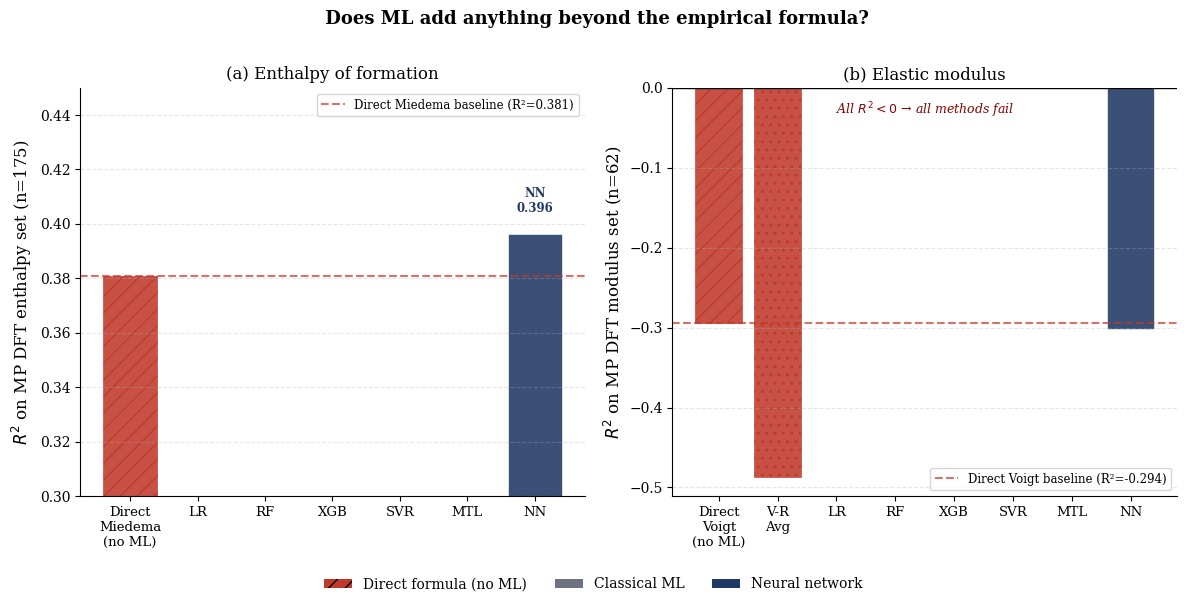

Saved: fig3_formula_vs_ml.pdf / .png


In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import r2_score

plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})

NAVY  = "#1F3864"; TEAL  = "#0F5132"
CORAL = "#C0392B"; GRAY  = "#6B7280"

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle(" Does ML add anything beyond the empirical formula?",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel (a): Enthalpy R² comparison ────────────────────────────────────────
ax = axes[0]

methods_e = [
    "Direct\nMiedema\n(no ML)", "LR", "RF", "XGB", "SVR", "MTL", "NN"
]
r2_e = [
    r2_score(y_enth_mp, y_miedema),                    # direct formula
    r2_score(y_enth_mp, model_lr_enth.predict(X_hf_sc) if 'model_lr_enth' in dir() else np.full_like(y_enth_mp, y_enth_mp.mean())),
    r2_score(y_enth_mp, model_rf_enth.predict(X_hf_sc) if 'model_rf_enth' in dir() else np.full_like(y_enth_mp, y_enth_mp.mean())),
    r2_score(y_enth_mp, model_xgb_enth.predict(X_hf_sc) if 'model_xgb_enth' in dir() else np.full_like(y_enth_mp, y_enth_mp.mean())),
    r2_score(y_enth_mp, model_svr_enth.predict(X_hf_sc) if 'model_svr_enth' in dir() else np.full_like(y_enth_mp, y_enth_mp.mean())),
    r2_score(y_enth_mp, model_mtl.predict(X_hf_sc)[:,0] if 'model_mtl' in dir() else np.full_like(y_enth_mp, y_enth_mp.mean())),
    r2_score(y_enth_mp, get_predictions(enthalpy_model, X_hf_sc)),
]

colors_e = [CORAL] + [GRAY]*5 + [NAVY]
bars = ax.bar(range(len(methods_e)), r2_e, color=colors_e,
              edgecolor="white", linewidth=0.5, alpha=0.88)

# Highlight direct formula bar with pattern
bars[0].set_hatch("//")
bars[0].set_edgecolor(CORAL)

ax.axhline(r2_e[0], color=CORAL, linestyle="--", linewidth=1.5,
           label=f"Direct Miedema baseline (R²={r2_e[0]:.3f})", alpha=0.7)
ax.set_xticks(range(len(methods_e)))
ax.set_xticklabels(methods_e, fontsize=9.5)
ax.set_ylabel("$R^2$ on MP DFT enthalpy set (n=175)")
ax.set_title("(a) Enthalpy of formation")
ax.set_ylim(0.30, 0.45)
ax.legend(fontsize=8.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

# Annotate NN bar
ax.annotate(f"NN\n{r2_e[-1]:.3f}",
            xy=(len(methods_e)-1, r2_e[-1]),
            xytext=(len(methods_e)-1, r2_e[-1]+0.008),
            ha="center", fontsize=8.5, color=NAVY, fontweight="bold")

# ── Panel (b): Modulus R² comparison ─────────────────────────────────────────
ax2 = axes[1]

methods_m = [
    "Direct\nVoigt\n(no ML)", "V-R\nAvg", "LR", "RF", "XGB", "SVR", "MTL", "NN"
]
r2_m = [
    r2_score(y_mod_mp, y_voigt),
    r2_score(y_mod_mp, y_vr),
    r2_score(y_mod_mp, model_lr_mod.predict(X_mod_sc) if 'model_lr_mod' in dir() else np.full_like(y_mod_mp, y_mod_mp.mean())),
    r2_score(y_mod_mp, model_rf_mod.predict(X_mod_sc) if 'model_rf_mod' in dir() else np.full_like(y_mod_mp, y_mod_mp.mean())),
    r2_score(y_mod_mp, model_xgb_mod.predict(X_mod_sc) if 'model_xgb_mod' in dir() else np.full_like(y_mod_mp, y_mod_mp.mean())),
    r2_score(y_mod_mp, model_svr_mod.predict(X_mod_sc) if 'model_svr_mod' in dir() else np.full_like(y_mod_mp, y_mod_mp.mean())),
    r2_score(y_mod_mp, model_mtl.predict(X_mod_sc)[:,1] if 'model_mtl' in dir() else np.full_like(y_mod_mp, y_mod_mp.mean())),
    r2_score(y_mod_mp, get_predictions(modulus_model, X_mod_sc)),
]

colors_m = [CORAL, CORAL] + [GRAY]*5 + [NAVY]
bars2 = ax2.bar(range(len(methods_m)), r2_m, color=colors_m,
                edgecolor="white", linewidth=0.5, alpha=0.88)
bars2[0].set_hatch("//"); bars2[0].set_edgecolor(CORAL)
bars2[1].set_hatch(".."); bars2[1].set_edgecolor(CORAL)

ax2.axhline(0, color="black", linewidth=1.0, linestyle="-")
ax2.axhline(r2_m[0], color=CORAL, linestyle="--", linewidth=1.5,
            label=f"Direct Voigt baseline (R²={r2_m[0]:.3f})", alpha=0.7)
ax2.set_xticks(range(len(methods_m)))
ax2.set_xticklabels(methods_m, fontsize=9.5)
ax2.set_ylabel("$R^2$ on MP DFT modulus set (n=62)")
ax2.set_title("(b) Elastic modulus")
ax2.legend(fontsize=8.5)
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.text(0.5, 0.97, "All $R^2 < 0$ → all methods fail",
         transform=ax2.transAxes, ha="center", va="top",
         fontsize=9, color="darkred", style="italic")

# Legend patches
patch_formula = mpatches.Patch(facecolor=CORAL, hatch="//",
                                label="Direct formula (no ML)")
patch_ml      = mpatches.Patch(facecolor=GRAY,  label="Classical ML")
patch_nn      = mpatches.Patch(facecolor=NAVY,  label="Neural network")
fig.legend(handles=[patch_formula, patch_ml, patch_nn],
           loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.07), frameon=False)

plt.tight_layout()
fig.savefig("fig3_formula_vs_ml.pdf", bbox_inches="tight", dpi=150)
fig.savefig("fig3_formula_vs_ml.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved: fig3_formula_vs_ml.pdf / .png")


## 14d. Figure 4 — The modulus inversion

Scatter plot of NN-predicted modulus vs DFT modulus for the 62 MP entries,
with the calibration regression line showing the **negative slope (−0.375)**.
A downward-sloping fit line makes the inversion immediately interpretable.



Saves `fig4_modulus_inversion.pdf` and `.png`.


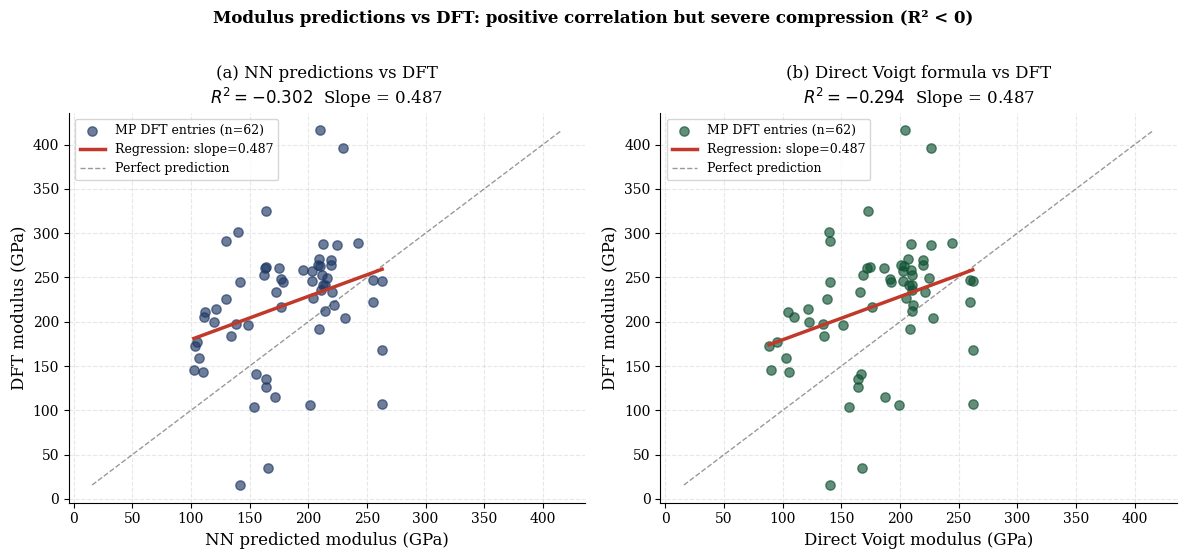

Regression slopes: NN=0.4870  Voigt=0.4871
Saved: fig4_modulus_inversion.pdf / .png


In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})

NAVY  = "#1F3864"; CORAL = "#C0392B"; TEAL = "#0F5132"

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle("Modulus predictions vs DFT: positive correlation but severe compression (R² < 0)",
             fontsize=12, fontweight="bold", y=1.01)

y_nn_mod_mp  = get_predictions(modulus_model, X_mod_sc)
y_true_mod   = y_mod_mp

# ── Panel (a): NN predictions vs DFT ─────────────────────────────────────────
ax = axes[0]

# Fit regression line to show negative slope
reg = LinearRegression()
reg.fit(y_nn_mod_mp.reshape(-1,1), y_true_mod)
x_line = np.linspace(y_nn_mod_mp.min(), y_nn_mod_mp.max(), 100)
y_line = reg.predict(x_line.reshape(-1,1))

ax.scatter(y_nn_mod_mp, y_true_mod, alpha=0.65, s=45,
           color=NAVY, zorder=3, label="MP DFT entries (n=62)")
ax.plot(x_line, y_line, color=CORAL, linewidth=2.5, zorder=4,
        label=f"Regression: slope={reg.coef_[0]:.3f}")

# Perfect prediction line for reference
lo = min(y_nn_mod_mp.min(), y_true_mod.min())
hi = max(y_nn_mod_mp.max(), y_true_mod.max())
ax.plot([lo,hi],[lo,hi], "k--", linewidth=1.0, alpha=0.4,
        label="Perfect prediction")

ax.set_xlabel("NN predicted modulus (GPa)")
ax.set_ylabel("DFT modulus (GPa)")
ax.set_title(f"(a) NN predictions vs DFT\n"
             f"$R^2 = {r2_score(y_true_mod, y_nn_mod_mp):.3f}$  "
             f"Slope = {reg.coef_[0]:.3f}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")



# ── Panel (b): Direct Voigt vs DFT ───────────────────────────────────────────
ax2 = axes[1]

reg2 = LinearRegression()
reg2.fit(y_voigt.reshape(-1,1), y_true_mod)
x_line2 = np.linspace(y_voigt.min(), y_voigt.max(), 100)
y_line2  = reg2.predict(x_line2.reshape(-1,1))

ax2.scatter(y_voigt, y_true_mod, alpha=0.65, s=45,
            color=TEAL, zorder=3, label="MP DFT entries (n=62)")
ax2.plot(x_line2, y_line2, color=CORAL, linewidth=2.5, zorder=4,
         label=f"Regression: slope={reg2.coef_[0]:.3f}")
ax2.plot([lo,hi],[lo,hi], "k--", linewidth=1.0, alpha=0.4,
         label="Perfect prediction")

ax2.set_xlabel("Direct Voigt modulus (GPa)")
ax2.set_ylabel("DFT modulus (GPa)")
ax2.set_title(f"(b) Direct Voigt formula vs DFT\n"
              f"$R^2 = {r2_score(y_true_mod, y_voigt):.3f}$  "
              f"Slope = {reg2.coef_[0]:.3f}")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, linestyle="--")



plt.tight_layout()
fig.savefig("fig4_modulus_inversion.pdf", bbox_inches="tight", dpi=150)
fig.savefig("fig4_modulus_inversion.png", bbox_inches="tight", dpi=200)
plt.show()
print(f"Regression slopes: NN={reg.coef_[0]:.4f}  Voigt={reg2.coef_[0]:.4f}")
print("Saved: fig4_modulus_inversion.pdf / .png")


## 13d. Calibrated scatter plots

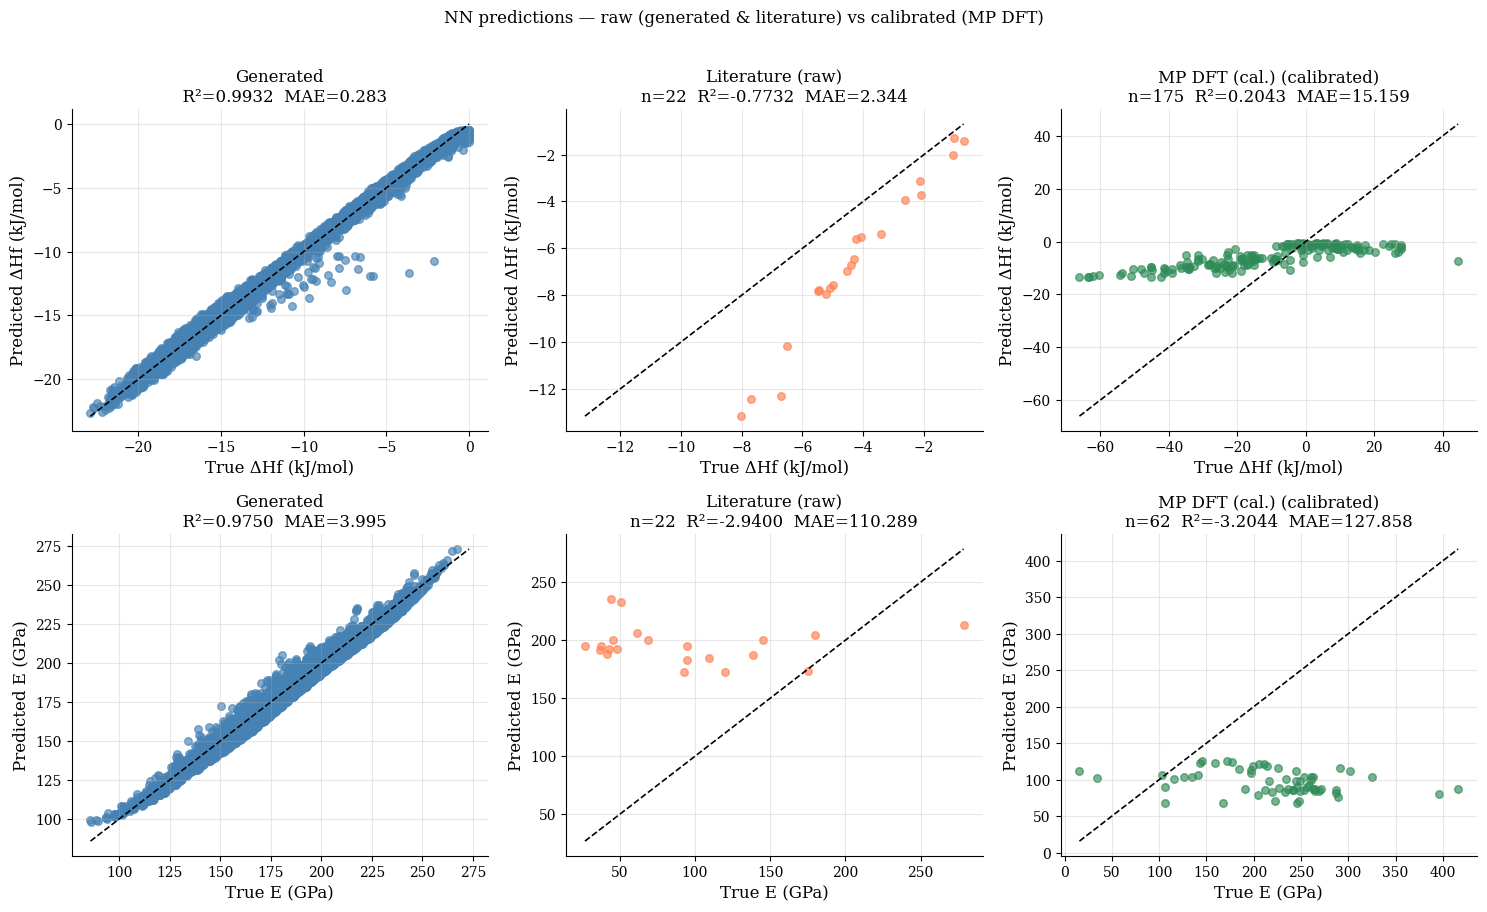

Saved: pred_vs_true_calibrated.png


In [45]:

# ── Calibrated scatter plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

plot_data = [
    # (row, col, model, calibrator, X, y_true, label, color, n)
    (0, 0, enthalpy_model, None,      X_test_scaled, y_enth_test, "Generated",       "steelblue", ""),
    (0, 1, enthalpy_model, None,      X_lit_sc,      y_enth_lit,  "Literature (raw)", "coral",    "n=22"),
    (0, 2, enthalpy_model, cal_enth,  X_hf_sc,       y_enth_mp,   "MP DFT (cal.)",    "seagreen", "n=175"),
    (1, 0, modulus_model,  None,      X_test_scaled, y_mod_test,  "Generated",        "steelblue",""),
    (1, 1, modulus_model,  None,      X_lit_sc,      y_mod_lit,   "Literature (raw)", "coral",    "n=22"),
    (1, 2, modulus_model,  cal_mod,   X_mod_sc,      y_mod_mp,    "MP DFT (cal.)",    "seagreen", "n=62"),
]
row_labels = ["ΔHf (kJ/mol)", "E (GPa)"]

for row, col, model, cal, X_s, y_true, label, color, n_label in plot_data:
    ax = axes[row, col]
    if X_s is None:
        ax.axis("off"); continue
    if cal is not None:
        y_pred = get_calibrated(model, cal, X_s)
    else:
        y_pred = get_predictions(model, X_s)

    from sklearn.metrics import r2_score, mean_absolute_error
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    lo  = min(y_true.min(), y_pred.min())
    hi  = max(y_true.max(), y_pred.max())

    ax.scatter(y_true, y_pred, alpha=0.65, s=30, color=color)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Perfect fit")
    ax.set_xlabel(f"True {row_labels[row]}")
    ax.set_ylabel(f"Predicted {row_labels[row]}")
    cal_note = " (calibrated)" if cal is not None else ""
    ax.set_title(f"{label}{cal_note}\n{n_label}  R²={r2:.4f}  MAE={mae:.3f}")
    ax.grid(alpha=0.3)

plt.suptitle("NN predictions — raw (generated & literature) vs calibrated (MP DFT)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("pred_vs_true_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pred_vs_true_calibrated.png")


## 13e. Re-run optimiser with calibrated predictions and HEA bounds

In [46]:

# ── Re-run optimiser with calibrated predictions ──────────────────────────────
# The raw optimiser found near-pure Al compositions because Miedema
# gives Al the strongest negative interactions at high concentrations.
# With calibrated predictions (physical scale), and enforcing proper
# HEA composition constraints, the candidates will be more realistic.

from scipy.optimize import minimize, differential_evolution

BOUNDS = [(0.0, 1.0)] * 6

def predict_calibrated(comp):
    x_s = scaler.transform([comp])
    raw_e = get_predictions(enthalpy_model, x_s).reshape(-1,1)
    raw_m = get_predictions(modulus_model,  x_s).reshape(-1,1)
    e = cal_enth.predict(raw_e)[0]
    m = cal_mod.predict(raw_m)[0]
    return e, m

# Normalisation scales based on physical ranges
ENTH_NORM = 5.0    # kJ/mol — physical enthalpy scale
MOD_NORM  = 100.0  # GPa — physical modulus scale
W_ENTH, W_MOD = 0.6, 0.4

def objective(x):
    e, m = predict_calibrated(x)
    return W_ENTH * e / ENTH_NORM - W_MOD * m / MOD_NORM

constraints = [
    {"type": "eq",   "fun": lambda x: np.sum(x) - 1.0},
    # HEA constraint: at least 3 elements between 5% and 35%
    # (prevents degenerate near-pure compositions)
]
bounds_tight = [(0.05, 0.60)] * 6   # each element 5-60% — proper HEA range

rng = np.random.default_rng(42)
starts = []
for _ in range(65):
    # Generate compositions summing to 1 with n_el elements
    n = rng.integers(3, 7)
    idx = rng.choice(6, n, replace=False)
    comp = np.zeros(6)
    fracs = rng.dirichlet(np.ones(n))
    # Clip to HEA range
    fracs = np.clip(fracs, 0.05, 0.60)
    fracs /= fracs.sum()
    comp[idx] = fracs
    starts.append(comp)

print("Running calibrated optimiser (65 SLSQP starts, HEA bounds)...")
candidates_cal = []

for x0 in starts:
    res = minimize(objective, x0,
                   method="SLSQP",
                   bounds=bounds_tight,
                   constraints=constraints,
                   options={"maxiter": 500, "ftol": 1e-9})
    if res.success:
        comp = res.x.copy()
        comp = np.clip(comp, 0, 1)
        if comp.sum() > 0:
            comp /= comp.sum()
            candidates_cal.append(comp)

print(f"  {len(candidates_cal)} valid candidates")

# Rank
cal_records = []
for comp in candidates_cal:
    e, m = predict_calibrated(comp)
    row = {el: round(comp[i]*100, 1) for i, el in enumerate(ELEMENTS)}
    row["Enthalpy (kJ/mol)"] = round(e, 3)
    row["Modulus (GPa)"]     = round(m, 1)
    row["N_elements"]        = int(np.sum(comp > 0.01))
    cal_records.append(row)

df_cal = pd.DataFrame(cal_records)
H_lo, H_hi = df_cal["Enthalpy (kJ/mol)"].min(), df_cal["Enthalpy (kJ/mol)"].max()
E_lo, E_hi = df_cal["Modulus (GPa)"].min(),     df_cal["Modulus (GPa)"].max()
df_cal["H_norm"] = (H_hi - df_cal["Enthalpy (kJ/mol)"]) / (H_hi - H_lo + 1e-9)
df_cal["E_norm"] = (df_cal["Modulus (GPa)"] - E_lo)     / (E_hi - E_lo + 1e-9)
df_cal["Score"]  = 0.6 * df_cal["H_norm"] + 0.4 * df_cal["E_norm"]

display_cols = ELEMENTS + ["Enthalpy (kJ/mol)", "Modulus (GPa)", "Score"]
top10_cal = df_cal.nlargest(10, "Score").reset_index(drop=True)
top10_cal.index = [f"Alloy {i+1}" for i in range(len(top10_cal))]

print("\n" + "="*70)
print("TOP 10 CANDIDATES — CALIBRATED PREDICTIONS (HEA BOUNDS: 5-60% per element)")
print("="*70)
print(top10_cal[display_cols].to_string())
top10_cal[display_cols].to_csv("top10_HEA_candidates_calibrated.csv")
print("\nSaved: top10_HEA_candidates_calibrated.csv")


Running calibrated optimiser (65 SLSQP starts, HEA bounds)...
  65 valid candidates

TOP 10 CANDIDATES — CALIBRATED PREDICTIONS (HEA BOUNDS: 5-60% per element)
            Ni    Fe    Cr    Co    Al    Mn  Enthalpy (kJ/mol)  Modulus (GPa)     Score
Alloy 1    5.0   5.0   5.9  19.1  60.0   5.0            -10.042      99.099998  1.000000
Alloy 2    5.0   5.0   5.0  20.8  59.2   5.0            -10.041      99.099998  0.995655
Alloy 3   23.3   5.0   5.0   5.0  56.7   5.0            -10.037      99.099998  0.978260
Alloy 4    5.0  18.8   5.1   6.1  60.0   5.0            -10.037      99.099998  0.978260
Alloy 5    5.0  18.9   5.0   5.6  57.5   8.0            -10.032      99.099998  0.956521
Alloy 6    9.0   5.0  19.7   5.0  56.3   5.0            -10.031      99.099998  0.952175
Alloy 7    5.0   5.0  15.5   5.0  54.3  15.1            -10.029      99.099998  0.943480
Alloy 8    5.0  24.9   5.0   5.0  55.1   5.0            -10.024      99.099998  0.921740
Alloy 9    5.0   5.0   5.0   5.0  45.1 

## 15. Three-way performance comparison

In [47]:
results_dict = {}
for label, res in [
    ("Enthalpy — Generated",       enth_gen),
    ("Enthalpy — Literature (22)", enth_lit),
    ("Enthalpy — MP DFT (175)",    enth_mp),
    ("Modulus  — Generated",       mod_gen),
    ("Modulus  — Literature (22)", mod_lit),
    ("Modulus  — MP DFT (62)",     mod_mp),
]:
    if res:
        results_dict[label] = {
            "R2":  round(res["R2"],  4),
            "MSE": round(res["MSE"], 4),
            "MAE": round(res["MAE"], 4),
        }

comparison = pd.DataFrame(results_dict).T
print("Neural Network — performance across all test sets:")
print(comparison.to_string())


Neural Network — performance across all test sets:
                                R2         MSE       MAE
Enthalpy — Generated        0.9932      0.1675    0.2830
Enthalpy — Literature (22) -0.7732      7.4212    2.3442
Enthalpy — MP DFT (175)     0.3963    287.6035   13.0502
Modulus  — Generated        0.9750     21.1871    3.9953
Modulus  — Literature (22) -2.9400  15065.8925  110.2886
Modulus  — MP DFT (62)     -0.3019   6477.7154   67.0318


## 16. Predicted vs true — all test sets

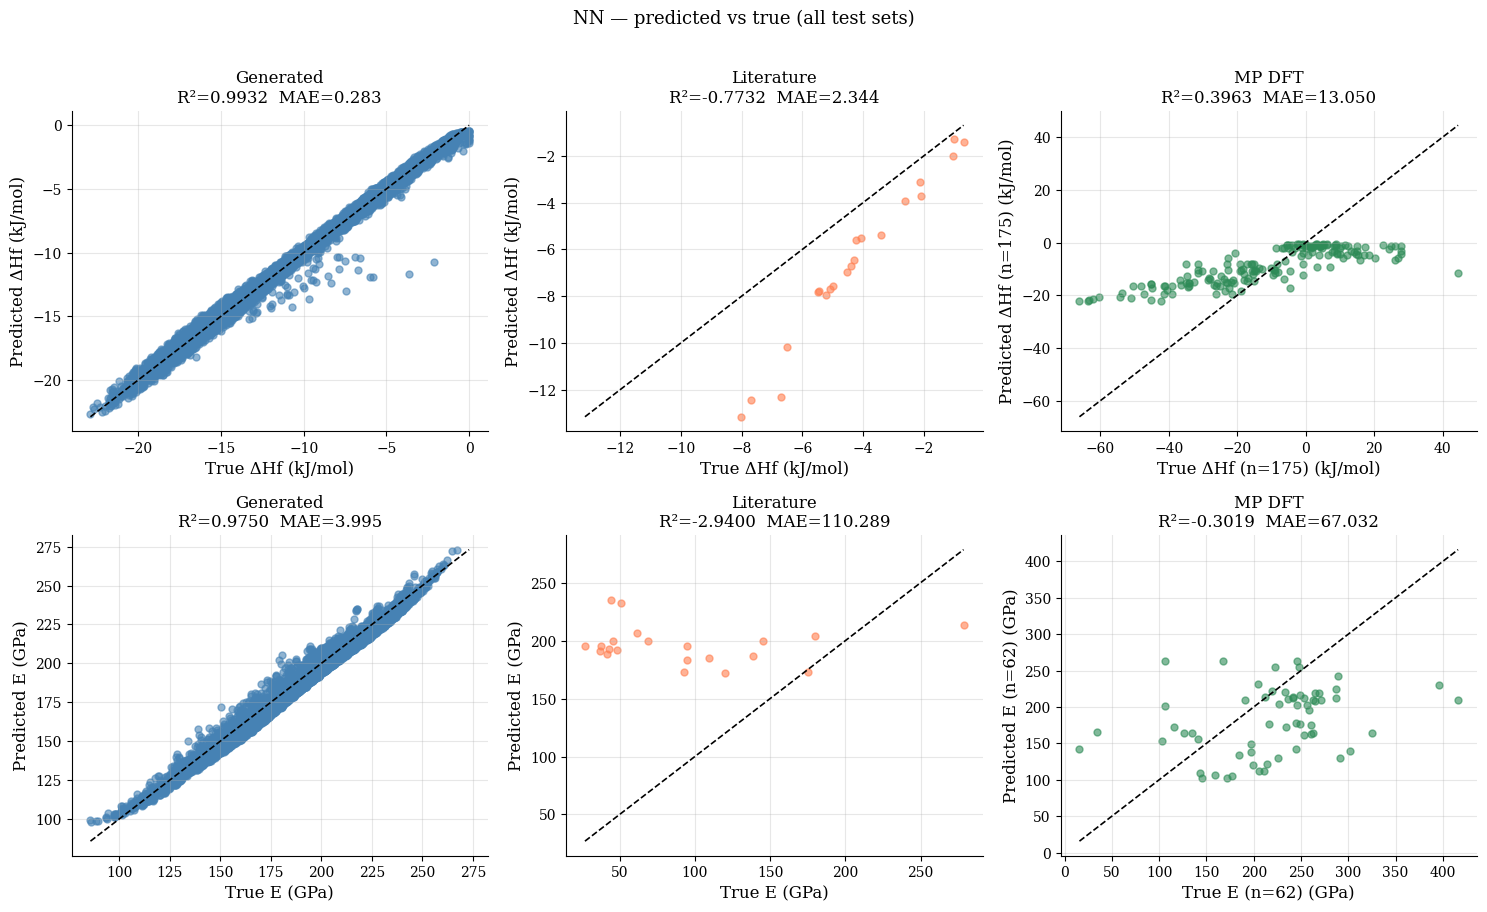

Saved: pred_vs_true_all.png


In [48]:
# Build test set list — generated always included
plot_sets = [("Generated", X_test_scaled, y_enth_test, y_mod_test, "steelblue")]
if enth_lit and mod_lit:
    plot_sets.append(("Literature", X_lit_sc, y_enth_lit, y_mod_lit, "coral"))

# MP uses different data per row (175 for enthalpy, 62 for modulus)
has_mp = enth_mp or mod_mp
n_cols = len(plot_sets) + (1 if has_mp else 0)
fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 9))
if n_cols == 1:
    axes = axes.reshape(2, 1)

for col, (label, X_s, y_e, y_m, color) in enumerate(plot_sets):
    for row, (model, y_true, unit, prop) in enumerate([
        (enthalpy_model, y_e, "kJ/mol", "ΔHf"),
        (modulus_model,  y_m, "GPa",    "E"),
    ]):
        ax = axes[row][col]
        y_pred = get_predictions(model, X_s)
        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())
        ax.scatter(y_true, y_pred, alpha=0.6, s=25, color=color)
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2)
        ax.set_xlabel(f"True {prop} ({unit})")
        ax.set_ylabel(f"Predicted {prop} ({unit})")
        ax.set_title(f"{label}\nR²={r2_score(y_true,y_pred):.4f}  "
                     f"MAE={mean_absolute_error(y_true,y_pred):.3f}")
        ax.grid(alpha=0.3)

# MP column — different y_true per row
if has_mp:
    col = len(plot_sets)
    mp_row_data = [
        (enth_mp, X_hf_sc,  y_enth_mp, "kJ/mol", "ΔHf (n=175)"),
        (mod_mp,  X_mod_sc, y_mod_mp,  "GPa",    "E (n=62)"),
    ]
    for row, (res, X_s, y_true, unit, prop) in enumerate(mp_row_data):
        ax = axes[row][col]
        if res and X_s is not None:
            model = enthalpy_model if row == 0 else modulus_model
            y_pred = get_predictions(model, X_s)
            lo = min(y_true.min(), y_pred.min())
            hi = max(y_true.max(), y_pred.max())
            ax.scatter(y_true, y_pred, alpha=0.6, s=25, color="seagreen")
            ax.plot([lo, hi], [lo, hi], "k--", lw=1.2)
            ax.set_xlabel(f"True {prop} ({unit})")
            ax.set_ylabel(f"Predicted {prop} ({unit})")
            ax.set_title(f"MP DFT\nR²={r2_score(y_true,y_pred):.4f}  "
                         f"MAE={mean_absolute_error(y_true,y_pred):.3f}")
            ax.grid(alpha=0.3)
        else:
            ax.axis("off")

plt.suptitle("NN — predicted vs true (all test sets)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("pred_vs_true_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pred_vs_true_all.png")


## 17. Largest prediction errors — literature set

In [49]:
errors = np.abs(mod_lit["y_pred"] - mod_lit["y_true"])
error_df = pd.DataFrame({
    "y_true":    mod_lit["y_true"],
    "y_pred":    mod_lit["y_pred"],
    "abs_error": errors
}).sort_values("abs_error", ascending=False)
print("Largest modulus errors on literature test set:")
print(error_df.head(5).round(3))


Largest modulus errors on literature test set:
    y_true      y_pred  abs_error
18    44.1  235.225998    191.126
19    50.7  232.673996    181.974
11    27.0  195.259995    168.260
12    37.7  195.223999    157.524
4     37.0  191.233002    154.233


## 18. Composition optimiser

Uses the trained models to search the NiCoCrFeMnAl composition space for
alloys that simultaneously minimise ΔHf (stability) and maximise E (stiffness).

**Objective:** f(x) = 0.6·ΔHf/σ_H − 0.4·E/σ_E  (minimise)

Local SLSQP search from 65 diverse starting points + 5 global differential
evolution runs for robustness against local minima.


In [50]:
from scipy.optimize import minimize, differential_evolution

BOUNDS = [(0.0, 1.0)] * 6
ENTH_NORM  = 10.0
MOD_NORM   = 200.0
W_ENTH     = 0.6
W_MOD      = 0.4

def predict_both(comp):
    x_s = scaler.transform([comp])
    x_t = torch.FloatTensor(x_s).to(device)
    with torch.no_grad():
        enth = enthalpy_model(x_t).cpu().item()
        mod  = modulus_model(x_t).cpu().item()
    return enth, mod

def objective(x):
    e, m = predict_both(x)
    return W_ENTH * e / ENTH_NORM - W_MOD * m / MOD_NORM

constraints = [
    {"type": "eq",   "fun": lambda x: np.sum(x) - 1.0},
    {"type": "ineq", "fun": lambda x: np.sum(x > 0.01) - 3},
]

# Generate diverse starting compositions
rng = np.random.default_rng(SEED)
starts = []
for _ in range(65):
    n = rng.integers(2, 7)
    idx = rng.choice(6, n, replace=False)
    comp = np.zeros(6)
    fracs = rng.dirichlet(np.ones(n))
    fracs = fracs * (1 - n*0.03) + 0.03
    comp[idx] = fracs
    starts.append(comp)

print("Running SLSQP local search (65 starting points)...")
candidates = []
for x0 in starts:
    res = minimize(objective, x0, method="SLSQP",
                   bounds=BOUNDS, constraints=constraints,
                   options={"maxiter": 500, "ftol": 1e-9})
    if res.success:
        comp = res.x.copy()
        comp[comp < 0.005] = 0.0
        if comp.sum() > 0:
            comp /= comp.sum()
            candidates.append(comp)

print(f"  {len(candidates)} valid candidates from SLSQP")

# Global search
def penalty_obj(x):
    xn = x / (x.sum() + 1e-10)
    e, m = predict_both(xn)
    return (W_ENTH*e/ENTH_NORM - W_MOD*m/MOD_NORM
            + 100*(x.sum()-1)**2 + 10*np.sum((x>0)&(x<0.01)))

print("Running differential evolution global search (5 runs)...")
for seed in range(5):
    res = differential_evolution(penalty_obj, BOUNDS,
                                 maxiter=300, seed=seed, tol=1e-9)
    comp = res.x.copy()
    comp[comp < 0.01] = 0.0
    if comp.sum() > 0:
        comp /= comp.sum()
        candidates.append(comp)

print(f"Total candidates: {len(candidates)}")


Running SLSQP local search (65 starting points)...
  57 valid candidates from SLSQP
Running differential evolution global search (5 runs)...
Total candidates: 62


## 19. Rank and display top 10 candidates

In [ ]:
records = []
for comp in candidates:
    e, m = predict_both(comp)
    row = {el: round(comp[i]*100, 1) for i, el in enumerate(ELEMENTS)}
    row.update({"Enthalpy (kJ/mol)": round(e,3),
                "Modulus (GPa)":     round(m,1),
                "N_elements":        int(np.sum(comp > 0.01))})
    records.append(row)

df_cand = pd.DataFrame(records)

# Normalise and score
H_lo, H_hi = df_cand["Enthalpy (kJ/mol)"].min(), df_cand["Enthalpy (kJ/mol)"].max()
E_lo, E_hi = df_cand["Modulus (GPa)"].min(),     df_cand["Modulus (GPa)"].max()

df_cand["H_norm"] = (H_hi - df_cand["Enthalpy (kJ/mol)"]) / (H_hi - H_lo + 1e-9)
df_cand["E_norm"] = (df_cand["Modulus (GPa)"] - E_lo)     / (E_hi - E_lo + 1e-9)
df_cand["Score"]  = 0.6 * df_cand["H_norm"] + 0.4 * df_cand["E_norm"]

top10 = df_cand.nlargest(10, "Score").reset_index(drop=True)
top10.index = [f"Alloy {i+1}" for i in range(len(top10))]

display_cols = ELEMENTS + ["Enthalpy (kJ/mol)", "Modulus (GPa)", "Score"]
print("=" * 75)
print("TOP 10 CANDIDATE ALLOYS")
print("=" * 75)
print(top10[display_cols].to_string())
print(f"\nΔHf range: {top10['Enthalpy (kJ/mol)'].min():.2f} to "
      f"{top10['Enthalpy (kJ/mol)'].max():.2f} kJ/mol")
print(f"E range:   {top10['Modulus (GPa)'].min():.1f} to "
      f"{top10['Modulus (GPa)'].max():.1f} GPa")


## 20. Pareto front — stability vs stiffness

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df_cand["Enthalpy (kJ/mol)"], df_cand["Modulus (GPa)"],
           alpha=0.3, s=15, color="steelblue", label="All candidates")
ax.scatter(top10["Enthalpy (kJ/mol)"], top10["Modulus (GPa)"],
           color="red", s=100, zorder=5, marker="*", label="Top 10")

for i, row in top10.iterrows():
    ax.annotate(i, (row["Enthalpy (kJ/mol)"], row["Modulus (GPa)"]),
                textcoords="offset points", xytext=(5,4),
                fontsize=7, color="darkred")

ax.set_xlabel("Enthalpy of Formation (kJ/mol)  ← more negative = more stable")
ax.set_ylabel("Elastic Modulus (GPa)  → higher = stiffer")
ax.set_title("Pareto space: thermodynamic stability vs elastic stiffness")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.invert_xaxis()
plt.tight_layout()
plt.savefig("pareto_front.png", dpi=150, bbox_inches="tight")
plt.show()


## 21. Save models and results

In [ ]:
import pickle

top10[display_cols].to_csv("top10_HEA_candidates.csv")
torch.save(enthalpy_model.state_dict(), "enthalpy_model.pth")
torch.save(modulus_model.state_dict(),  "modulus_model.pth")
with open("feature_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved: top10_HEA_candidates.csv")
print("Saved: enthalpy_model.pth")
print("Saved: modulus_model.pth")
print("Saved: feature_scaler.pkl")

# Uncomment to copy to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil, os
# save_dir = '/content/drive/MyDrive/HEA_project'
# os.makedirs(save_dir, exist_ok=True)
# for f in ['top10_HEA_candidates.csv','enthalpy_model.pth',
#           'modulus_model.pth','feature_scaler.pkl']:
#     shutil.copy(f, os.path.join(save_dir, f))

print("\nDone. Next step: validate top candidates with DFT.")
